# ESoC 2026 — CLAAS: Stone Audio Fingerprint

Goal: understand what a stone impact *sounds like* in the frequency domain compared to normal harvesting.

Uses confirmed metallic stone events (VoltageSignal > 2000, header On) as ground truth labels.  
Extracts 4 audio features from windows around those events and compares them against normal harvesting windows.

| Feature | What it measures |
|---------|------------------|
| Short-time RMS | Sudden energy burst in a tight time window |
| High-frequency energy ratio | Energy above 4kHz vs total — impacts are wideband |
| Time-domain kurtosis | Impulsiveness — stones are spiky, crop noise is continuous |
| MFCCs | Full spectral shape fingerprint |

In [12]:
from asammdf import MDF
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import kurtosis
import librosa
import librosa.display
from pathlib import Path

DATA_DIR = Path("data")
MF4_FILES = sorted(DATA_DIR.glob("*.mf4"))

SR = 44100          # audio sample rate
VOLT_THRESHOLD = 2000   # fixed metallic stone threshold
WINDOW_BEFORE = 0.5     # seconds of audio before spike to analyse
WINDOW_AFTER  = 0.1     # seconds after spike (context only)
WINDOW_LEN    = WINDOW_BEFORE + WINDOW_AFTER  # 600ms total
MIN_SUSTAIN   = 5       # samples spike must stay above threshold

print(f"Stone window: {int(WINDOW_BEFORE*1000)}ms before spike + {int(WINDOW_AFTER*1000)}ms after")
print(f"Window samples at {SR}Hz: {int(WINDOW_LEN * SR)}")

Stone window: 500ms before spike + 100ms after
Window samples at 44100Hz: 26460


## 1. Fixed labeling functions (VoltageSignal > 2000, per-episode)

In [2]:
def get_episodes(status_channel):
    """Episode detection that handles recording starting mid-On."""
    s = status_channel.samples.astype(str)
    t = status_channel.timestamps
    changes = np.where(s[:-1] != s[1:])[0]
    events = [(t[0], s[0])]
    for i in changes:
        events.append((t[i+1], s[i+1]))
    episodes, ep_start = [], None
    for ev_time, ev_state in events:
        if ev_state == 'On' and ep_start is None:
            ep_start = ev_time
        elif ev_state == 'Off' and ep_start is not None:
            episodes.append((ep_start, ev_time))
            ep_start = None
    if ep_start is not None:
        episodes.append((ep_start, t[-1]))
    return episodes


def get_stone_spike_times(volt_channel, episodes, threshold=VOLT_THRESHOLD, min_sustain=MIN_SUSTAIN):
    """
    Find first onset of each sustained voltage spike within header-On episodes.
    Merges spikes within 1s of each other (same stone event).
    Returns list of absolute spike onset times.
    """
    v = volt_channel.samples
    t = volt_channel.timestamps
    spike_times = []

    for ep_start, ep_end in episodes:
        mask = (t >= ep_start) & (t <= ep_end)
        v_ep, t_ep = v[mask], t[mask]
        if len(v_ep) < min_sustain:
            continue
        above = v_ep > threshold
        # Sustain filter
        sustained = np.zeros_like(above)
        count = 0
        for k in range(len(above)):
            if above[k]:
                count += 1
                if count >= min_sustain:
                    sustained[k - min_sustain + 1:k + 1] = True
            else:
                count = 0
        edges = np.diff(sustained.astype(int))
        onsets = t_ep[np.where(edges == 1)[0] + 1]
        # Merge within 1s
        for st in onsets:
            if not spike_times or st - spike_times[-1] > 1.0:
                spike_times.append(float(st))

    return spike_times


print("Labeling functions defined — VoltageSignal threshold:", VOLT_THRESHOLD)

Labeling functions defined — VoltageSignal threshold: 2000


## 2. Extract stone windows and normal windows from all runs

In [13]:
def extract_audio_window(audio_channel, center_time, before, after):
    """Return audio samples in [center_time - before, center_time + after]."""
    t = audio_channel.timestamps
    s = audio_channel.samples
    mask = (t >= center_time - before) & (t <= center_time + after)
    return s[mask].astype(np.float32)


stone_windows  = []   # list of (run_name, spike_time, audio_array)
normal_windows = []   # list of (run_name, sample_time, audio_array)
rng = np.random.default_rng(42)

for f in MF4_FILES:
    mf      = MDF(f)
    audio   = mf.get("Sensor1")
    volt    = mf.get("VoltageSignal")
    status  = mf.get("Status")

    episodes   = get_episodes(status)
    spike_times = get_stone_spike_times(volt, episodes)

    # Stone windows: WINDOW_BEFORE before spike, WINDOW_AFTER after
    for st in spike_times:
        w = extract_audio_window(audio, st, WINDOW_BEFORE, WINDOW_AFTER)
        expected = int(WINDOW_LEN * SR)
        if len(w) >= expected * 0.9:   # allow 10% tolerance at file edges
            stone_windows.append((f.stem, st, w))

    # Normal windows: random 600ms chunks during On periods, >2s from any spike
    for ep_start, ep_end in episodes:
        ep_dur = ep_end - ep_start
        if ep_dur < WINDOW_LEN + 4:
            continue
        # Sample up to 3 normal windows per episode
        n_samples = min(3, int(ep_dur / (WINDOW_LEN + 2)))
        candidates = rng.uniform(ep_start + 1, ep_end - WINDOW_LEN - 1, size=n_samples * 5)
        count = 0
        for ct in candidates:
            too_close = any(abs(ct - st) < 2.0 for st in spike_times)
            if too_close:
                continue
            w = extract_audio_window(audio, ct + WINDOW_BEFORE, WINDOW_BEFORE, WINDOW_AFTER)
            if len(w) >= int(WINDOW_LEN * SR) * 0.9:
                normal_windows.append((f.stem, ct, w))
                count += 1
            if count >= n_samples:
                break

print(f"Stone windows  collected: {len(stone_windows)}")
print(f"Normal windows collected: {len(normal_windows)}")
print()
print("Stone events per run:")
for f in MF4_FILES:
    n = sum(1 for r, _, _ in stone_windows if r == f.stem)
    print(f"  {f.stem}: {n}")

Stone windows  collected: 10
Normal windows collected: 63

Stone events per run:
  Messung_2025-05-09_08-59-34: 0
  Messung_2025-05-14_16-02-23: 2
  Messung_2025-05-20_16-30-26: 2
  Messung_2025-10-01_09-42-16: 5
  Messung_2025-10-01_17-18-12: 1


## 3. Waveform comparison — stone vs normal

t=0 = metal detector spike. The stone impact in the audio should appear somewhere in the orange shaded zone (before t=0).

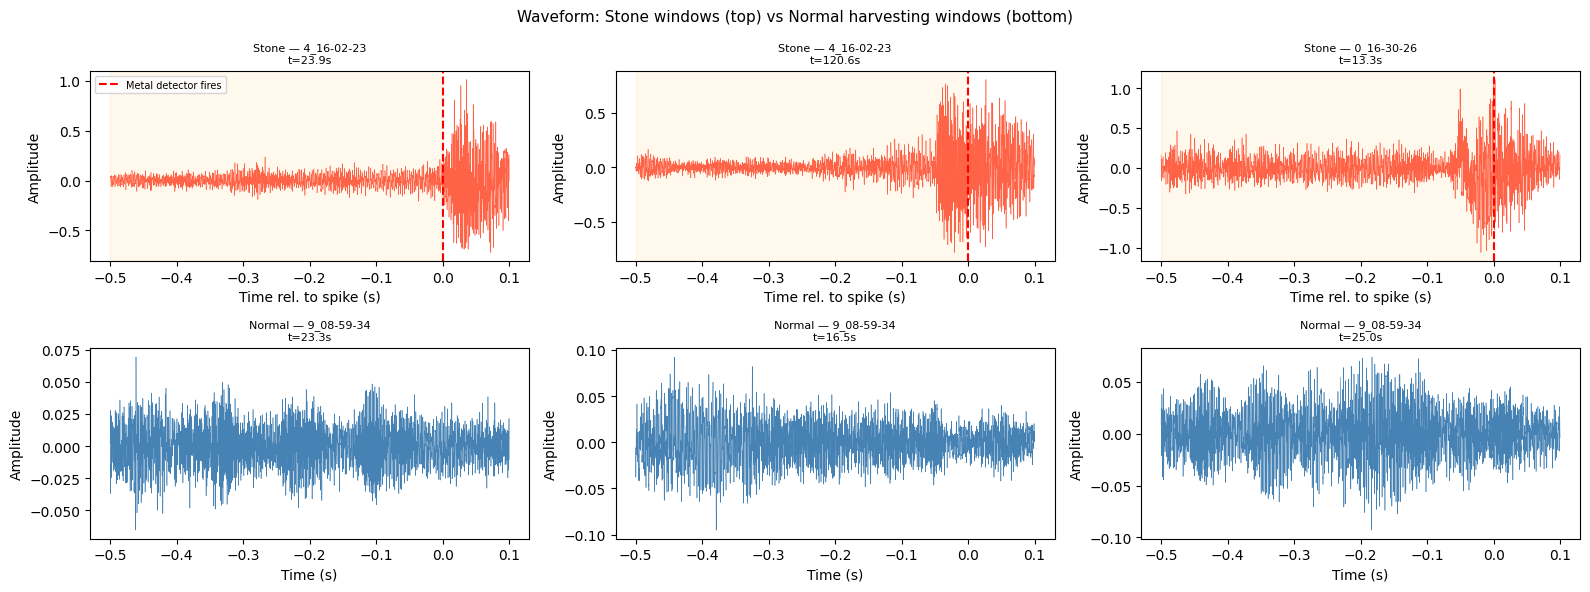

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 6), sharey=False)
fig.suptitle("Waveform: Stone windows (top) vs Normal harvesting windows (bottom)", fontsize=11)

n_show = min(3, len(stone_windows))
for i in range(n_show):
    run, spike_t, w = stone_windows[i]
    t_axis = np.linspace(-WINDOW_BEFORE, WINDOW_AFTER, len(w))
    axes[0, i].plot(t_axis, w, lw=0.4, color='tomato')
    axes[0, i].axvline(0, color='red', lw=1.5, linestyle='--', label='Metal detector fires')
    axes[0, i].axvspan(-WINDOW_BEFORE, 0, alpha=0.07, color='orange')
    axes[0, i].set_title(f"Stone — {run[-10:]}\nt={spike_t:.1f}s", fontsize=8)
    axes[0, i].set_xlabel("Time rel. to spike (s)")
    axes[0, i].set_ylabel("Amplitude")
    if i == 0:
        axes[0, i].legend(fontsize=7)

n_show_n = min(3, len(normal_windows))
for i in range(n_show_n):
    run, ct, w = normal_windows[i]
    t_axis = np.linspace(-WINDOW_BEFORE, WINDOW_AFTER, len(w))
    axes[1, i].plot(t_axis, w, lw=0.4, color='steelblue')
    axes[1, i].set_title(f"Normal — {run[-10:]}\nt={ct:.1f}s", fontsize=8)
    axes[1, i].set_xlabel("Time (s)")
    axes[1, i].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

## 4. Spectrogram comparison — where do the frequencies differ?

A stone impact should appear as a vertical bright stripe before t=0 in the stone spectrogram.  
The normal spectrogram should show stable horizontal bands (steady engine/crop noise).

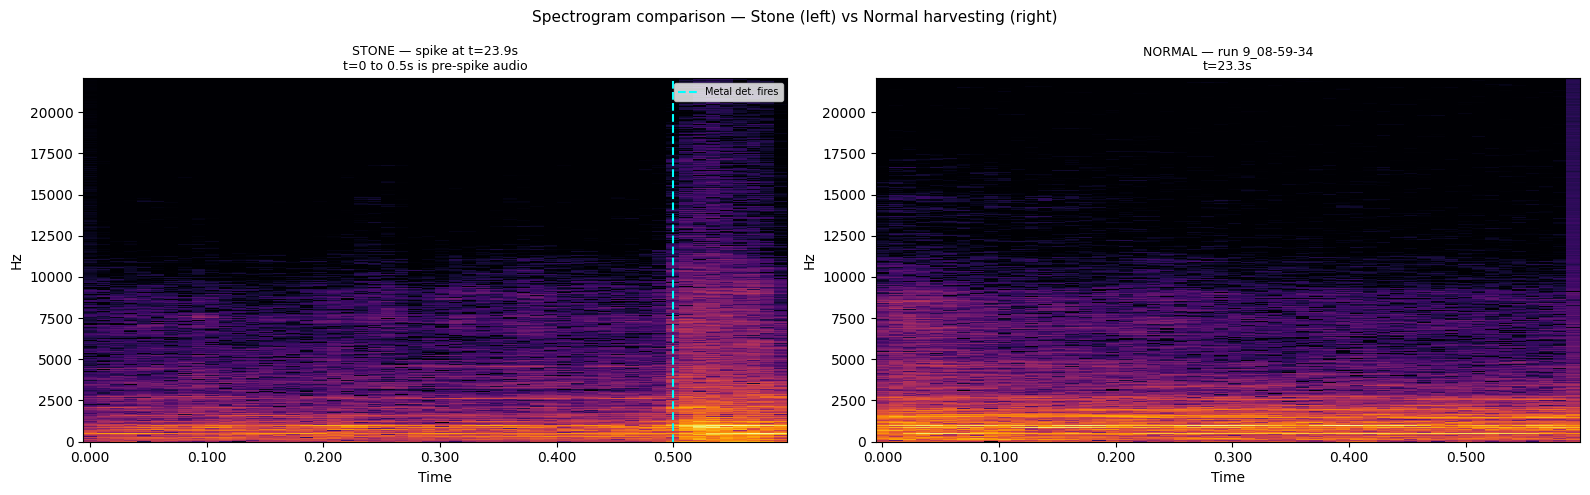

What to look for:
  Stone: vertical bright stripe somewhere before the cyan line (t=0.5s)
  Normal: stable horizontal bands — no sudden vertical burst


In [15]:
def plot_spectrogram(ax, audio, title, sr=SR, mark_t0=False):
    n_fft = 2048
    hop   = 512
    S = np.abs(librosa.stft(audio, n_fft=n_fft, hop_length=hop))
    S_db = librosa.amplitude_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=sr, hop_length=hop,
                              x_axis='time', y_axis='hz', ax=ax, cmap='inferno')
    ax.set_title(title, fontsize=9)
    if mark_t0:
        ax.axvline(WINDOW_BEFORE, color='cyan', lw=1.5, linestyle='--', label='Metal det. fires')
        ax.legend(fontsize=7, loc='upper right')

# Pick the stone event with the strongest spike for the clearest demo
best_stone  = stone_windows[0]
best_normal = normal_windows[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Spectrogram comparison — Stone (left) vs Normal harvesting (right)", fontsize=11)

plot_spectrogram(axes[0], best_stone[2],
                 f"STONE — spike at t={best_stone[1]:.1f}s\nt=0 to {WINDOW_BEFORE:.1f}s is pre-spike audio",
                 mark_t0=True)
plot_spectrogram(axes[1], best_normal[2],
                 f"NORMAL — run {best_normal[0][-10:]}\nt={best_normal[1]:.1f}s")

plt.tight_layout()
plt.show()

print("What to look for:")
print("  Stone: vertical bright stripe somewhere before the cyan line (t=0.5s)")
print("  Normal: stable horizontal bands — no sudden vertical burst")

## 5. Feature 1 — Short-time RMS energy profile

RMS in 10ms sliding windows. A stone impact creates a sharp localised energy spike.  
Normal harvesting has steady, slowly-varying energy.

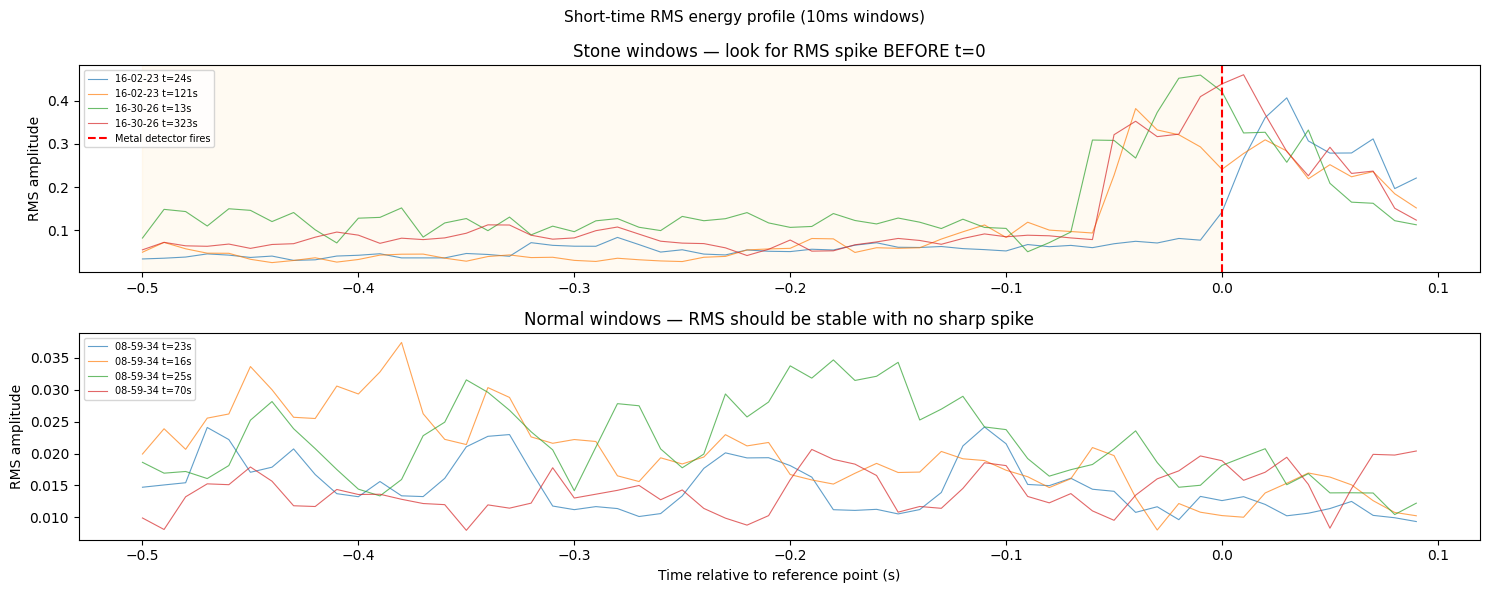

In [16]:
def rms_profile(audio, sr=SR, window_ms=10):
    """RMS energy in non-overlapping windows. Returns (times, rms_values)."""
    w = int(sr * window_ms / 1000)
    n = len(audio) // w
    rms = np.array([np.sqrt(np.mean(audio[i*w:(i+1)*w]**2)) for i in range(n)])
    times = np.arange(n) * window_ms / 1000 - WINDOW_BEFORE
    return times, rms

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=False)
fig.suptitle("Short-time RMS energy profile (10ms windows)", fontsize=11)

for run, spike_t, w in stone_windows[:4]:
    times, rms = rms_profile(w)
    axes[0].plot(times, rms, lw=0.8, alpha=0.7, label=f"{run[-8:]} t={spike_t:.0f}s")
axes[0].axvline(0, color='red', lw=1.5, linestyle='--', label='Metal detector fires')
axes[0].axvspan(-WINDOW_BEFORE, 0, alpha=0.05, color='orange')
axes[0].set_title("Stone windows — look for RMS spike BEFORE t=0")
axes[0].set_ylabel("RMS amplitude")
axes[0].legend(fontsize=7, loc='upper left')

for run, ct, w in normal_windows[:4]:
    times, rms = rms_profile(w)
    axes[1].plot(times, rms, lw=0.8, alpha=0.7, label=f"{run[-8:]} t={ct:.0f}s")
axes[1].set_title("Normal windows — RMS should be stable with no sharp spike")
axes[1].set_ylabel("RMS amplitude")
axes[1].set_xlabel("Time relative to reference point (s)")
axes[1].legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

## 6. Feature 2 — High-frequency energy ratio

Ratio of energy above 4kHz to total energy, computed over 20ms frames.  
Stone impacts produce energy across all frequencies including high bands.  
Engine/crop noise is dominated by lower frequencies.

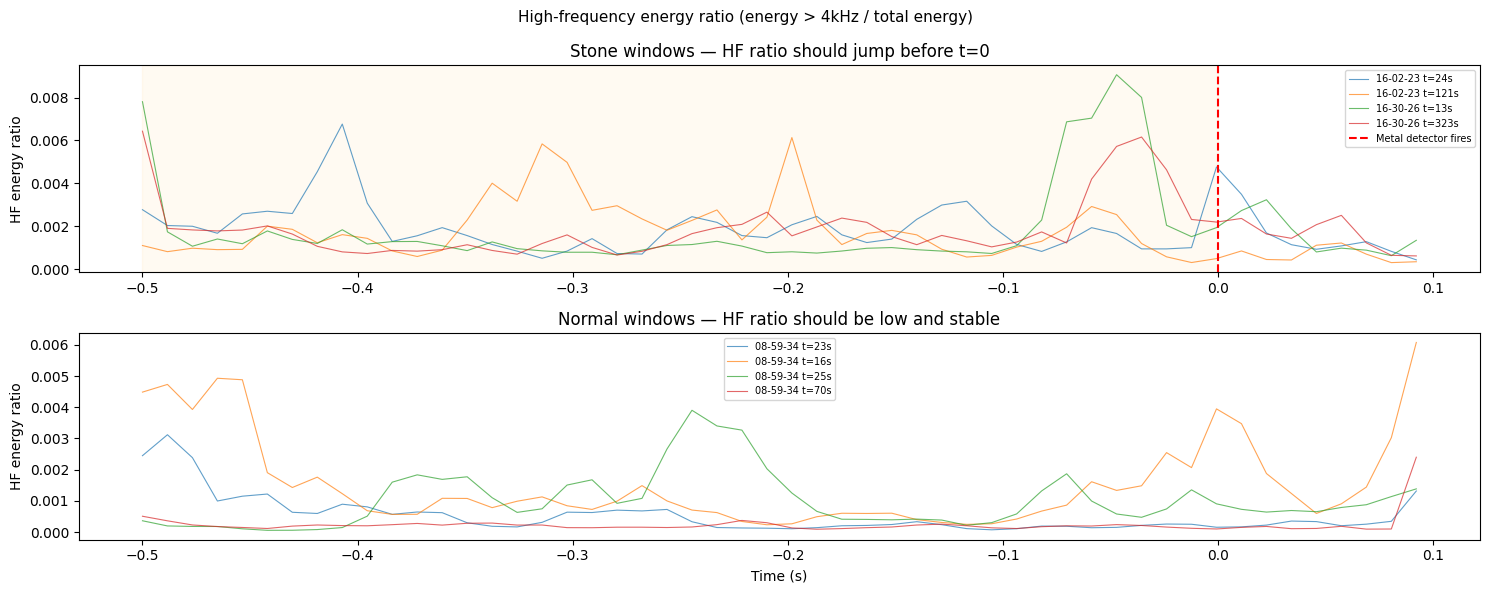

In [17]:
def hf_energy_ratio(audio, sr=SR, n_fft=2048, hop_length=512, cutoff_hz=4000):
    """
    Ratio of high-frequency (> cutoff_hz) energy to total energy per STFT frame.
    Returns (frame_times, ratio_array).
    """
    S = np.abs(librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)) ** 2
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    hf_mask = freqs >= cutoff_hz
    total  = S.sum(axis=0) + 1e-12
    hf     = S[hf_mask].sum(axis=0)
    ratio  = hf / total
    frame_times = librosa.frames_to_time(
        np.arange(S.shape[1]), sr=sr, hop_length=hop_length
    ) - WINDOW_BEFORE
    return frame_times, ratio

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=False)
fig.suptitle("High-frequency energy ratio (energy > 4kHz / total energy)", fontsize=11)

for run, spike_t, w in stone_windows[:4]:
    ft, ratio = hf_energy_ratio(w)
    axes[0].plot(ft, ratio, lw=0.8, alpha=0.7, label=f"{run[-8:]} t={spike_t:.0f}s")
axes[0].axvline(0, color='red', lw=1.5, linestyle='--', label='Metal detector fires')
axes[0].axvspan(-WINDOW_BEFORE, 0, alpha=0.05, color='orange')
axes[0].set_title("Stone windows — HF ratio should jump before t=0")
axes[0].set_ylabel("HF energy ratio")
axes[0].legend(fontsize=7)

for run, ct, w in normal_windows[:4]:
    ft, ratio = hf_energy_ratio(w)
    axes[1].plot(ft, ratio, lw=0.8, alpha=0.7, label=f"{run[-8:]} t={ct:.0f}s")
axes[1].set_title("Normal windows — HF ratio should be low and stable")
axes[1].set_ylabel("HF energy ratio")
axes[1].set_xlabel("Time (s)")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

## 7. Feature 3 — Time-domain kurtosis (impulsiveness)

Kurtosis measures how "spiky" a signal is. A normal distribution (smooth noise) has kurtosis=3.  
An impulsive impact event has very high kurtosis — most samples are quiet, with a few extreme peaks.

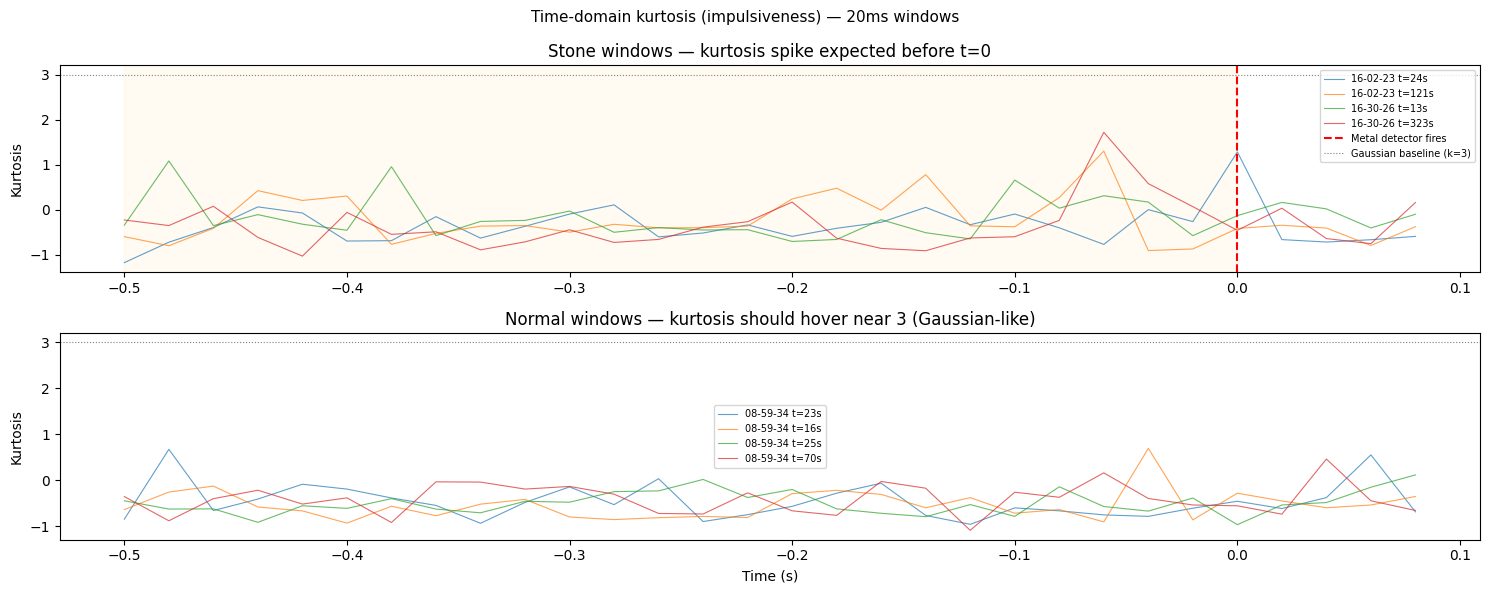

In [18]:
def kurtosis_profile(audio, sr=SR, window_ms=20):
    """Kurtosis in non-overlapping windows. Returns (times, kurtosis_values)."""
    w = int(sr * window_ms / 1000)
    n = len(audio) // w
    kurt = np.array([kurtosis(audio[i*w:(i+1)*w]) for i in range(n)])
    times = np.arange(n) * window_ms / 1000 - WINDOW_BEFORE
    return times, kurt

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=False)
fig.suptitle("Time-domain kurtosis (impulsiveness) — 20ms windows", fontsize=11)

for run, spike_t, w in stone_windows[:4]:
    times, kurt = kurtosis_profile(w)
    axes[0].plot(times, kurt, lw=0.8, alpha=0.7, label=f"{run[-8:]} t={spike_t:.0f}s")
axes[0].axvline(0, color='red', lw=1.5, linestyle='--', label='Metal detector fires')
axes[0].axvspan(-WINDOW_BEFORE, 0, alpha=0.05, color='orange')
axes[0].axhline(3, color='grey', lw=0.8, linestyle=':', label='Gaussian baseline (k=3)')
axes[0].set_title("Stone windows — kurtosis spike expected before t=0")
axes[0].set_ylabel("Kurtosis")
axes[0].legend(fontsize=7)

for run, ct, w in normal_windows[:4]:
    times, kurt = kurtosis_profile(w)
    axes[1].plot(times, kurt, lw=0.8, alpha=0.7, label=f"{run[-8:]} t={ct:.0f}s")
axes[1].axhline(3, color='grey', lw=0.8, linestyle=':')
axes[1].set_title("Normal windows — kurtosis should hover near 3 (Gaussian-like)")
axes[1].set_ylabel("Kurtosis")
axes[1].set_xlabel("Time (s)")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

## 8. Feature 4 — MFCCs

13 Mel-frequency cepstral coefficients capture the overall spectral shape.  
If stone and normal windows have systematically different MFCC patterns, a classifier can learn to separate them.

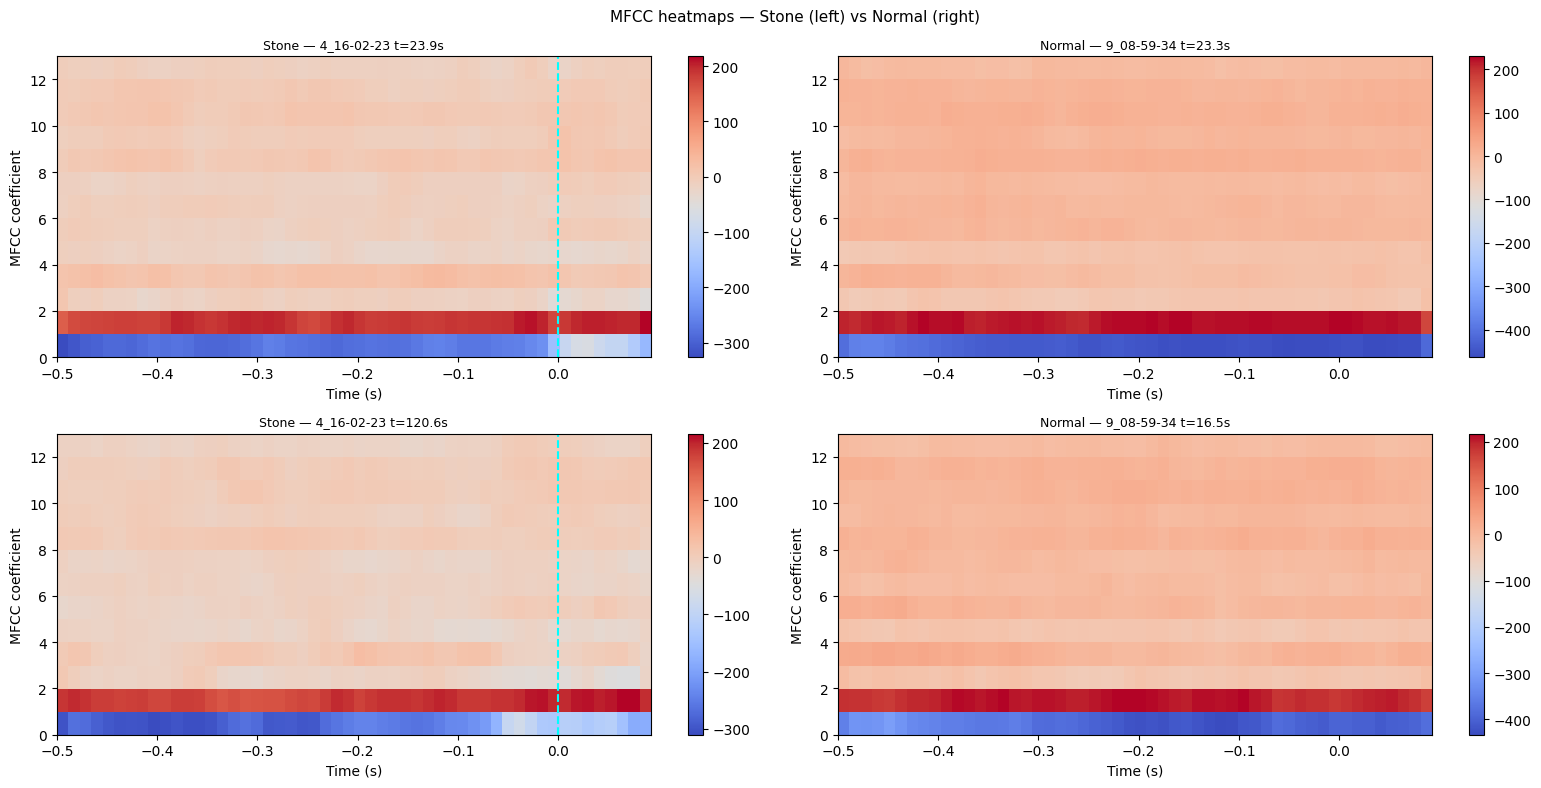

In [19]:
def compute_mfcc(audio, sr=SR, n_mfcc=13):
    return librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle("MFCC heatmaps — Stone (left) vs Normal (right)", fontsize=11)

for col, (label, windows) in enumerate([("Stone", stone_windows[:2]), ("Normal", normal_windows[:2])]):
    for row, (run, ref_t, w) in enumerate(windows):
        if row >= 2:
            break
        mfcc = compute_mfcc(w)
        t_axis = librosa.frames_to_time(np.arange(mfcc.shape[1]), sr=SR) - WINDOW_BEFORE
        im = axes[row, col].imshow(
            mfcc, aspect='auto', origin='lower', cmap='coolwarm',
            extent=[t_axis[0], t_axis[-1], 0, mfcc.shape[0]]
        )
        axes[row, col].set_ylabel("MFCC coefficient")
        axes[row, col].set_xlabel("Time (s)")
        axes[row, col].set_title(f"{label} — {run[-10:]} t={ref_t:.1f}s", fontsize=9)
        if label == "Stone":
            axes[row, col].axvline(0, color='cyan', lw=1.5, linestyle='--')
        plt.colorbar(im, ax=axes[row, col])

plt.tight_layout()
plt.show()

## 9. Feature distributions — the ML view

Compute a single scalar summary per window for each feature.  
If stone and normal distributions are well separated → the feature is useful for a classifier.  
If they overlap heavily → the feature alone won't work.

In [20]:
def summarise_window(audio, sr=SR):
    """Return a dict of scalar feature summaries for one audio window."""
    # Use only the pre-spike zone (before t=0) to simulate real-time detection
    n_pre = int(WINDOW_BEFORE * sr)
    pre = audio[:n_pre]

    # RMS: peak RMS in 10ms windows
    w10 = int(sr * 0.01)
    rms_vals = [np.sqrt(np.mean(pre[i*w10:(i+1)*w10]**2))
                for i in range(len(pre)//w10)]
    peak_rms = float(np.max(rms_vals)) if rms_vals else 0.0

    # HF ratio: mean over frames
    S = np.abs(librosa.stft(pre, n_fft=2048, hop_length=512)) ** 2
    freqs = librosa.fft_frequencies(sr=sr, n_fft=2048)
    hf_mask = freqs >= 4000
    mean_hf_ratio = float(np.mean(S[hf_mask].sum(0) / (S.sum(0) + 1e-12)))

    # Kurtosis: max over 20ms windows
    w20 = int(sr * 0.02)
    kurt_vals = [kurtosis(pre[i*w20:(i+1)*w20]) for i in range(len(pre)//w20)]
    max_kurtosis = float(np.max(kurt_vals)) if kurt_vals else 0.0

    # MFCC: mean of each coefficient (13 values → take overall std as one scalar)
    mfcc = librosa.feature.mfcc(y=pre, sr=sr, n_mfcc=13)
    mfcc_std = float(np.mean(np.std(mfcc, axis=1)))  # mean temporal variance across coefficients

    return {
        'peak_rms':      peak_rms,
        'hf_ratio':      mean_hf_ratio,
        'max_kurtosis':  max_kurtosis,
        'mfcc_variance': mfcc_std,
    }

stone_feats  = pd.DataFrame([summarise_window(w) for _, _, w in stone_windows])
normal_feats = pd.DataFrame([summarise_window(w) for _, _, w in normal_windows])

stone_feats['label']  = 'stone'
normal_feats['label'] = 'normal'
all_feats = pd.concat([stone_feats, normal_feats], ignore_index=True)

print("Stone feature summary:")
print(stone_feats.drop(columns='label').describe().round(4))
print("\nNormal feature summary:")
print(normal_feats.drop(columns='label').describe().round(4))

Stone feature summary:
       peak_rms  hf_ratio  max_kurtosis  mfcc_variance
count   10.0000   10.0000       10.0000        10.0000
mean     0.3064    0.0020        2.6333        10.2525
std      0.1594    0.0009        4.4828         2.6008
min      0.0655    0.0009        0.0861         6.4068
25%      0.1710    0.0016        0.3676         8.3612
50%      0.3829    0.0019        1.0060        10.6082
75%      0.4344    0.0021        1.6163        11.4771
max      0.4654    0.0043       14.5671        14.7257

Normal feature summary:
       peak_rms  hf_ratio  max_kurtosis  mfcc_variance
count   63.0000   63.0000       63.0000        63.0000
mean     0.0647    0.0015        0.5539         7.8404
std      0.0502    0.0016        0.5527         1.9664
min      0.0124    0.0001       -0.2215         4.2773
25%      0.0277    0.0005        0.1581         6.4183
50%      0.0415    0.0011        0.4619         7.4776
75%      0.0922    0.0019        0.7066         9.1638
max      0.2186  

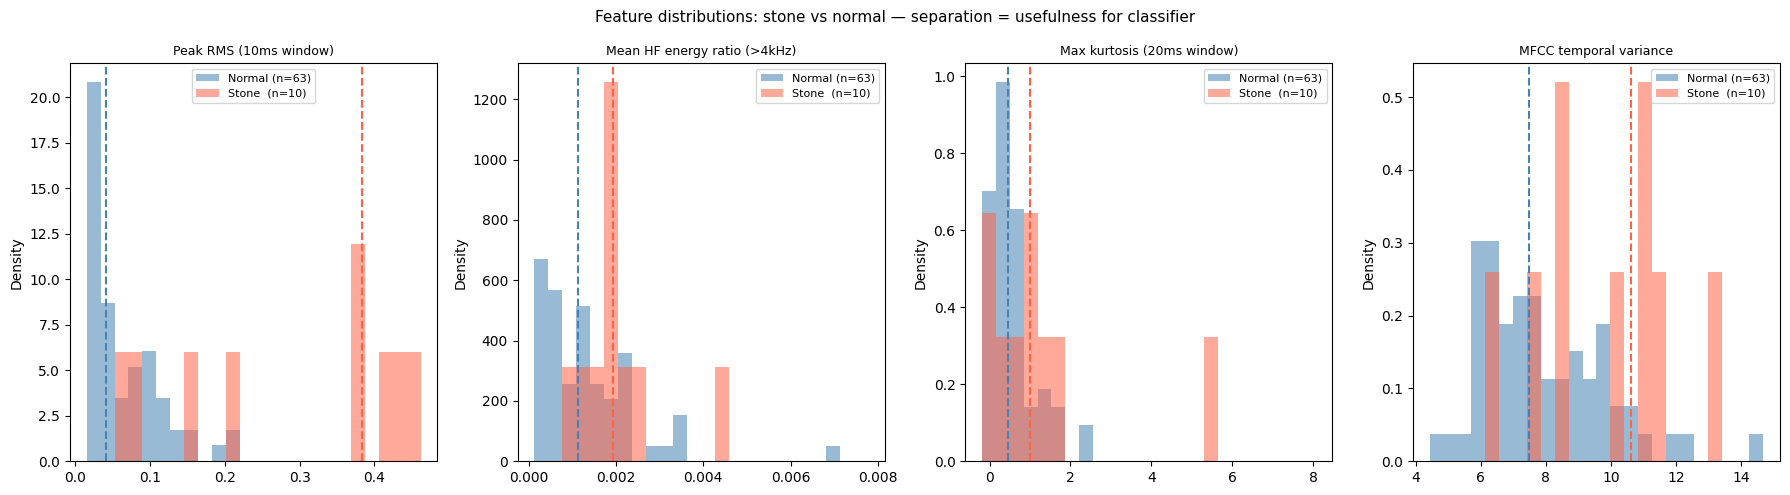


Median ratio (stone / normal) per feature — higher = better separation:
  peak_rms                 : 9.22x
  hf_ratio                 : 1.69x
  max_kurtosis             : 2.18x
  mfcc_variance            : 1.42x


In [21]:
features = ['peak_rms', 'hf_ratio', 'max_kurtosis', 'mfcc_variance']
titles   = [
    'Peak RMS (10ms window)',
    'Mean HF energy ratio (>4kHz)',
    'Max kurtosis (20ms window)',
    'MFCC temporal variance'
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Feature distributions: stone vs normal — separation = usefulness for classifier", fontsize=11)

for ax, feat, title in zip(axes, features, titles):
    s_vals = stone_feats[feat].dropna()
    n_vals = normal_feats[feat].dropna()

    all_vals = np.concatenate([s_vals, n_vals])
    bins = np.linspace(np.percentile(all_vals, 1), np.percentile(all_vals, 99), 25)

    ax.hist(n_vals, bins=bins, alpha=0.55, color='steelblue', label=f'Normal (n={len(n_vals)})', density=True)
    ax.hist(s_vals, bins=bins, alpha=0.55, color='tomato',    label=f'Stone  (n={len(s_vals)})', density=True)

    ax.axvline(n_vals.median(), color='steelblue', lw=1.5, linestyle='--')
    ax.axvline(s_vals.median(), color='tomato',    lw=1.5, linestyle='--')

    ax.set_title(title, fontsize=9)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\nMedian ratio (stone / normal) per feature — higher = better separation:")
for feat in features:
    ratio = stone_feats[feat].median() / (normal_feats[feat].median() + 1e-12)
    print(f"  {feat:25s}: {ratio:.2f}x")

## 10. Summary — which features are worth using?

Read the distribution plots above:
- **Separated histograms** = the feature distinguishes stone from normal → useful for a classifier
- **Overlapping histograms** = the feature cannot separate them alone → combine with others or discard

The dashed vertical lines show the median for each class. The further apart they are relative to the spread, the more useful the feature.

These 4 scalar features (or a combination) are the basis for the model in Task 2.  
For non-metallic stones: if they physically produce a similar impact, these same features should trigger —  
the model will not know or care whether the stone was metallic or not.